In [3]:
import pandas as pd

In [4]:
url = "https://raw.githubusercontent.com/AnnaShestova/salary-years-simple-linear-regression/master/Salary_Data.csv"
dataset = pd.read_csv(url)

In [5]:
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [10]:
X = dataset[['YearsExperience']].values
Y = dataset['Salary'].values

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=42)

In [12]:
from sklearn.svm import LinearSVR
model = LinearSVR(epsilon=0.5)
model.fit(X_train, Y_train)

c:\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVR(epsilon=0.5)

In [13]:
Y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error
print(mean_squared_error(Y_pred, Y_test))
print(root_mean_squared_error(Y_pred, Y_test))

8178555280.058055
90435.36520663835


In [15]:
import numpy as np
import matplotlib.pyplot as plt

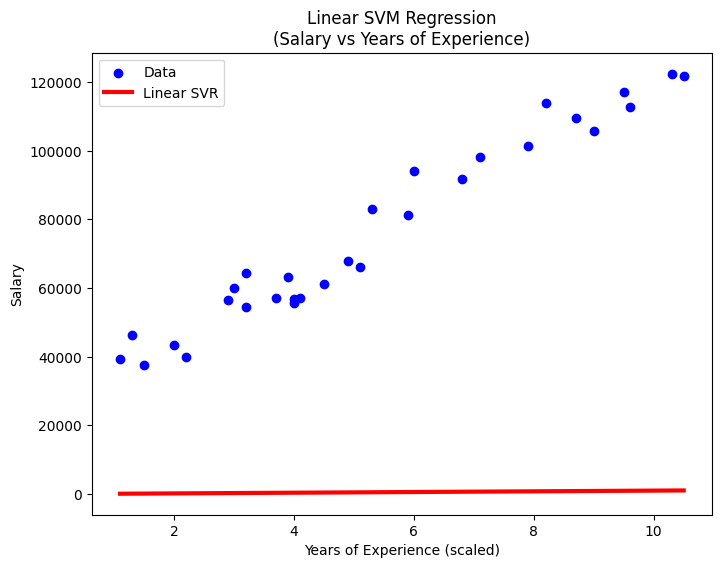

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Data')
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_plot, model.predict(X_plot), color='red', linewidth=3, label='Linear SVR')
plt.xlabel('Years of Experience (scaled)')
plt.ylabel('Salary')
plt.title('Linear SVM Regression\n(Salary vs Years of Experience)')
plt.legend()
plt.show()